### Assignment 1 code to run

In [1]:
# -----------------------------
# Parameters
# -----------------------------
gamma = 0.9
lam=0.5 # used in poisson distribution
xi1, xi2 = 5, 7

# Location states
DEPOT = 0
AT_1 = 1   # engineer is @ machine 1
AT_2 = 2   # engineer is @ machine 2
REP_1 = 3   # 1 unit of remaining time for corrective maintenance @1. Note that this state only exists when x1=xi1. 
REP_2 = 4   # 1 unit of remaining time for corrective maintenance @2. Note that this state only exists when x2=xi2. 

# -----------------------------
# State space
# -----------------------------

# NOTE: we keep only states that are possible

states = []

for x1 in range(xi1 + 1):
    for x2 in range(xi2 + 1):

        # always allowed locations
        for l in [DEPOT, AT_1, AT_2]:
            states.append((x1, x2, l))

        # corrective maintenance state for machine 1
        if x1 == xi1:
            states.append((x1, x2, REP_1))

        # corrective maintenance state for machine 2
        if x2 == xi2:
            states.append((x1, x2, REP_2))


# -----------------------------
# Poisson probabilities
# -----------------------------
def poisson_pmf(y,lam, max_y):
    """
    Returns the y-th element of the list:
    [P(X=0), P(X=1), ..., P(X=max_y-1), P(X>=max_y)]
    with X ~ Poisson(lam)
    """

    probs = []

    if max_y>0:
        # P(X=0)
        p = math.exp(-lam)
        probs.append(p)

        # Compute P(X=k) recursively
        for k in range(1, max_y):
            p = p * lam / k
            probs.append(p)

        # Tail probability
        tail = 1.0 - sum(probs)
        probs.append(tail)
    elif max_y==0:
        probs=[1]
    return probs[y]

# -----------------------------
# Action space
# -----------------------------
#Note that this is further refined below when considering the possible acitons
ACTIONS = ["nothing", "travel_1", "travel_2", "travel_depot",
           "maintain_1", "maintain_2", "continue maintenance"]


"""
The action "continue maintenance" is a pseudo-action to only indicate that we are forced to continue the corrective maintenance for a second period of time and should not impact the results        
"""    

# -----------------------------
# Feasible actions
# -----------------------------

# used in e-gridy!!!

def feasible_actions(state): 
    # based on a state gets me a function of feasible actions! 
    x1, x2, l = state
    
    acts = []
    
    # forced continuation during repair
    if l in (REP_1, REP_2):
        acts = ["continue maintenance"]

    elif l == DEPOT:
        if x2 == xi2 and x1 == xi1:
            acts = ["travel_1", "travel_2"]
        elif x2 == xi2 and x1 < xi1:
            acts = ["travel_2"]
        elif x1 == xi1 and x2 < xi2:
            acts = ["travel_1"]
        else:
            acts = ["nothing", "travel_1", "travel_2"]

    elif l == AT_1:
        if x1 == xi1:
            acts = ["maintain_1"]
        elif x1 < xi1 and x2 == xi2: 
            acts = ["travel_depot"]
        else:
            acts = ["travel_depot", "maintain_1","nothing"]  
        

    elif l == AT_2:
        if x2 == xi2:
            acts = ["maintain_2"]
        elif x2 < xi2 and x1 == xi1: 
            acts = ["travel_depot"]
        else:
            acts = ["travel_depot", "maintain_2","nothing"] 

    return acts

# -----------------------------
# Cost
# -----------------------------
def cost(state, action):
    x1, x2, l = state

    c = 0

    if action == "maintain_1":
        if x1 < xi1:
            c += 1 
        else:
            c += 5 
                
    if action == "maintain_2":
        if x2 < xi2:
            c += 1 
        else:
            c += 5 

    # unavailability cost
    if x1 == xi1 :
        c += 1
    if x2 == xi2 :
        c += 1

    return c


# -----------------------------
# Transitions
# -----------------------------
def transitions(state, action):
    x1, x2, l = state
    trans = {}

    # ---------------- forced repair completion
    if l == REP_1:
        # in the next unit, maintenance completed → machine 1 becomes healthy
        for y in range(xi2-x2+1):
            p = poisson_pmf(y,lam, xi2-x2)
            x2n = min(x2 + y, xi2)
            trans[(0, x2n, AT_1)] = \
                trans.get((0, x2n, AT_1), 0) + p
        return trans

    elif l == REP_2:
        # in the next unit, maintenance completed → machine 2 becomes healthy
        for y in range(xi1-x1+1):
            p = poisson_pmf(y,lam,xi1-x1)
            x1n = min(x1 + y, xi1)
            trans[(x1n, 0, AT_2)] = \
                trans.get((x1n, 0, AT_2), 0) + p
        return trans

    # ---------------- travel
    elif action == "travel_1":
        for y1 in range(xi1-x1+1):
            for y2 in range(xi2-x2+1):
                p = poisson_pmf(y1,lam,xi1-x1) * poisson_pmf(y2,lam,xi2-x2)
                x1n = min(x1 + y1, xi1)
                x2n = min(x2 + y2, xi2)
                trans[(x1n, x2n, AT_1)] = \
                    trans.get((x1n, x2n, AT_1), 0) + p
        return trans

    elif action == "travel_2":
        for y1 in range(xi1-x1+1):
            for y2 in range(xi2-x2+1):
                p = poisson_pmf(y1,lam,xi1-x1) * poisson_pmf(y2,lam,xi2-x2)
                x1n = min(x1 + y1, xi1)
                x2n = min(x2 + y2, xi2)
                trans[(x1n, x2n, AT_2)] = \
                    trans.get((x1n, x2n, AT_2), 0) + p
        return trans
    
    elif action == "travel_depot":
        for y1 in range(xi1-x1+1):
            for y2 in range(xi2-x2+1):
                p = poisson_pmf(y1,lam,xi1-x1) * poisson_pmf(y2,lam,xi2-x2)
                x1n = min(x1 + y1, xi1)
                x2n = min(x2 + y2, xi2)
                trans[(x1n, x2n, DEPOT)] = \
                    trans.get((x1n, x2n, DEPOT), 0) + p

    # ---------------- maintenance start
    elif action == "maintain_1":
        # preventive = 1 period
        if x1 < xi1:
            for y in range(xi2-x2+1):
                p = poisson_pmf(y,lam, xi2-x2)
                x2n = min(x2 + y, xi2)
                trans[(0, x2n, AT_1)] = \
                    trans.get((0, x2n, AT_1), 0) + p
        elif x1 == xi1:
            # corrective = 2 periods
            for y in range(xi2-x2+1):
                p = poisson_pmf(y,lam,xi2-x2)
                x2n = min(x2 + y, xi2)
                trans[(xi1, x2n, REP_1)] = \
                    trans.get((xi1, x2n, REP_1), 0) + p
        return trans

    elif action == "maintain_2":
        if x2 < xi2:
            for y in range(xi1-x1+1):
                p = poisson_pmf(y,lam,xi1-x1)
                x1n = min(x1 + y, xi1)
                trans[(x1n, 0, AT_2)] = \
                    trans.get((x1n, 0, AT_2), 0) + p
        elif x2==xi2:
            for y in range(xi1-x1+1):
                p = poisson_pmf(y,lam,xi1-x1)
                x1n = min(x1 + y, xi1)
                trans[(x1n, xi2, REP_2)] = \
                    trans.get((x1n, xi2, REP_2), 0) + p
        return trans

    elif action == "nothing":
        for y1 in range(xi1-x1+1):
            for y2 in range(xi2-x2+1):
                p = poisson_pmf(y1,lam,xi1-x1) * poisson_pmf(y2,lam,xi2-x2)
                x1n = min(x1 + y1, xi1)
                x2n = min(x2 + y2, xi2)
                trans[(x1n, x2n, l)] = \
                    trans.get((x1n, x2n, l), 0) + p
    return trans

# Assignment 2 — Task 1: Q-Learning for Optimal Maintenance Policy

This notebook implements **Q-Learning** (off-policy TD control) to recover the optimal
maintenance policy for the two-machine system from Assignment 1, using only observed
interactions — no knowledge of transition probabilities is used during training.

**Notebook structure:**
1. Policy Iteration oracle (ground-truth V*)
2. Q-Learning: algorithm design, pseudocode, and justification
3. Training run with motivated hyperparameters + convergence analysis
4. Policy extraction and comparison with PI
5. Hyperparameter sensitivity study

---
**Prerequisites:** Execute the Assignment 1 MDP definition cell **before** running this notebook.  
Required in scope: `states`, `ACTIONS`, `feasible_actions`, `cost`, `transitions`,
`gamma`, `xi1`, `xi2`, `DEPOT`, `AT_1`, `AT_2`, `REP_1`, `REP_2`.

In [2]:
import numpy as np
import random
import math
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 1 — Policy Iteration Oracle

We run Policy Iteration with **full model knowledge** to obtain V*(s) — the ground-truth
optimal value function. This serves two purposes:
- **Oracle MSE**: an objective measure of how close Q-Learning converges to the true optimum
- **Policy comparison**: verifying Q-Learning recovers the same decisions

In a real model-free setting we would not have this oracle. We use it here because we
do have the model from Assignment 1, and the assignment explicitly asks for a comparison.

In [3]:
V_PI     = {s: 0.0             for s in states}
policy_PI = {s: feasible_actions(s)[0] for s in states}


def _pi_eval(pol, V, tol=1e-10):
    while True:
        delta = 0.0
        for s in states:
            a     = pol[s]
            v_new = cost(s, a) + gamma * sum(
                p * V[sp] for sp, p in transitions(s, a).items()
            )
            delta = max(delta, abs(V[s] - v_new))
            V[s]  = v_new
        if delta < tol:
            break


def _pi_improve(pol, V):
    stable = True
    for s in states:
        old_a            = pol[s]
        best_a, best_q   = old_a, float("inf")
        for a in feasible_actions(s):
            q = cost(s, a) + gamma * sum(
                p * V[sp] for sp, p in transitions(s, a).items()
            )
            if q < best_q:
                best_q, best_a = q, a
        if best_a != old_a:
            pol[s] = best_a
            stable = False
    return stable


_pi_iters = 0
while True:
    _pi_iters += 1
    _pi_eval(policy_PI, V_PI)
    if _pi_improve(policy_PI, V_PI):
        break

print(f"PI converged in {_pi_iters} iterations")
print(f"V*(0,0,DEPOT) = {V_PI[(0, 0, DEPOT)]:.4f}")
print(f"V*(5,7,DEPOT) = {V_PI[(5, 7, DEPOT)]:.4f}  (worst degradation state)")

PI converged in 5 iterations
V*(0,0,DEPOT) = 2.4620
V*(5,7,DEPOT) = 16.8511  (worst degradation state)


## 2 — Q-Learning: Algorithm Design

### Why Q-Learning?
Policy/Value Iteration (Assignment 1) required explicit knowledge of `transitions()` and
`cost()`. Q-Learning is **model-free**: it learns Q*(s,a) purely from interactions,
observing costs and next states without knowing their distributions.

### Cost Minimisation vs. Reward Maximisation
Standard Q-Learning **maximises** reward. Our objective **minimises** cost.
This flips every `max` → `min` and `argmax` → `argmin` throughout.
The update rule becomes:

$$Q(s,a) \leftarrow Q(s,a) + \alpha_k \cdot
\bigl[\underbrace{r + \gamma \cdot \min_{a'} Q(s', a')}_{\text{Q-Learning target}}
- Q(s,a)\bigr]$$

### Why Q-Learning is Off-Policy
- **Behaviour policy** (how we act): $\varepsilon$-greedy — sometimes random, sometimes greedy
- **Target policy** (what we learn): purely greedy — update always uses $\min_{a'} Q(s', a')$

We explore with one policy but learn about a different (optimal) one.
No importance-sampling correction is needed — this is the key advantage of Q-Learning
over on-policy methods like SARSA.

### Why No Natural Absorbing State
Machines continuously degrade and are repaired — the MDP never terminates.
Episodes are therefore capped at a derived length $T_{\max}$ such that the discounted
tail beyond $T_{\max}$ is negligible (< $10^{-8}$). Any learning signal from steps
beyond $T_{\max}$ would contribute less than $10^{-8}$ to the Q-values and can be
safely ignored.

### Pseudocode

```
INPUT  : K (max episodes), α₀ (learning rate scale), ε₀ (exploration scale)
DERIVE : T_max = ⌈ log(ε_tol·(1−γ)/R_max) / log(γ) ⌉
INIT   : Q(s,a) = +∞  for infeasible (s,a)   ← never selected by argmin
         Q(s,a) =  0  for feasible   (s,a)
         N(s,a) =  1  for feasible   (s,a)    ← visit counter (starts at 1)
         consec ← 0                           ← consecutive convergence counter

FOR k = 1 … K:
    s₀  ← Uniform(S)                          ← random start (GLIE cond. 1)
    ε_k ← ε₀ / k                              ← decays (GLIE cond. 2)

    FOR t = 0 … T_max − 1:
        WITH prob ε_k : a ← random feasible action in s    (explore)
        ELSE          : a ← argmin_a Q(s,a), random tie-break  (exploit)

        r  ← cost(s, a)
        s' ← sample from P(· | s, a)

        α_k       ← α₀ / N(s,a)              ← Robbins-Monro schedule
        Q(s,a)    ← Q(s,a) + α_k·[r + γ·min_{a'} Q(s',a') − Q(s,a)]
        N(s,a)    ← N(s,a) + 1
        s         ← s'

    ΔQ_k ← max_{feasible (s,a)} |Q_k(s,a) − Q_{k−1}(s,a)|

    IF ΔQ_k < τ:
        consec ← consec + 1
        IF consec ≥ C : STOP          ← converged (C consecutive episodes below τ)
    ELSE:
        consec ← 0                    ← reset on any large change

RETURN Q,  π*(s) = argmin_a Q(s,a)
```

### Hyperparameter Justification

| Parameter | Value | Justification |
|---|---|---|
| α₀ = 1 | `alpha_scaling=1` | Effective rate = 1/N(s,a) — satisfies Robbins-Monro (∑α=∞, ∑α²<∞) |
| ε₀ = 1 | `epsilon_0=1` | Rate = 1/(k+1) → 0, all (s,a) visited infinitely — satisfies GLIE |
| T_max ≈ 216 | derived | Tail bound: γ^T·R_max/(1−γ) < 10⁻⁸ |
| R_max = 7 | derived | Worst step: both machines failed (cost 2) + corrective maint. (cost 5) |
| τ = 10⁻³ | `dq_tau=1e-3` | ~0.01% of Q-value scale (Q values are O(10)) |
| C = 20 | `consec_threshold=20` | 20 consecutive stable episodes — robust to Poisson noise, easy to verify |

### Convergence Criterion

Policy-stability (counting episodes where `argmin Q` does not change) is **not robust**
for stochastic MDPs: Poisson transitions cause Q-values for near-tied actions to
fluctuate, making `argmin` oscillate indefinitely even when the algorithm has converged.

Instead we use a **consecutive threshold on max |ΔQ|**:
> Stop when max|ΔQ| remains below τ = 10⁻³ for C = 20 consecutive episodes.

This directly measures Q-value convergence, is robust to exploration noise, and is
straightforward to report: *"we stop when Q-values change by less than 10⁻³ for
20 consecutive episodes."*


## 3 — Implementation

In [4]:
# ---------------------------------------------------------------------------
# Episode length formula
# Derivation: we want γ^T · R_max / (1−γ) < error
#   → T > log(error·(1−γ)/R_max) / log(γ)
#   → T_max = ceil( log(error·(1−γ)/R_max) / log(γ) )
# R_max = 7: worst single step = both machines failed (cost 2)
#            + corrective maintenance on one (cost 5).
# ---------------------------------------------------------------------------
def getLengthEpisode(gamma_val=0.9, r_max=7.0, error=1e-8):
    return int(np.ceil(
        np.log(error * (1.0 - gamma_val) / r_max) / np.log(gamma_val)
    ))


T_MAX = getLengthEpisode(gamma_val=gamma)
print(f"Episode length: T_MAX = {T_MAX} steps  (γ={gamma}, R_max=7, error=1e-8)")

# Index mappings: state/action → integer row/column in Q-table
states_indexes  = {s: i for i, s in enumerate(states)}
actions_indexes = {a: i for i, a in enumerate(ACTIONS)}

# Pre-compute feasible actions, transition distributions, and costs once.
# All three caches are built here so the inner training loop (T_MAX × n_episodes
# steps) does pure array indexing rather than Python function calls.
feasible_cache = {s: feasible_actions(s) for s in states}

# cost_cache: cost(s,a) is deterministic — cache it to eliminate ~10M Python calls.
cost_cache = {(s, a): cost(s, a) for s in states for a in feasible_cache[s]}

# trans_cache: store next-state lists and pre-normalised numpy probability arrays.
# np.random.choice requires probabilities that sum to exactly 1.0;
# explicit normalisation guards against float rounding errors in Poisson PMFs.
trans_cache = {}
for s in states:
    for a in feasible_cache[s]:
        td    = transitions(s, a)
        p_arr = np.array(list(td.values()), dtype=np.float64)
        p_arr /= p_arr.sum()           # ensure exact sum = 1.0
        trans_cache[(s, a)] = (list(td.keys()), p_arr)

print(f"Cached {len(trans_cache)} feasible (state, action) distributions")
print(f"States: {len(states)},  Actions: {len(ACTIONS)}")

Episode length: T_MAX = 216 steps  (γ=0.9, R_max=7, error=1e-8)
Cached 369 feasible (state, action) distributions
States: 158,  Actions: 7


In [5]:
def qLearning(n_episodes, alpha_power=1.0, epsilon_0=1.0,
              V_oracle=None, mse_interval=200,
              dq_tau=1e-3, consec_threshold=20, seed=None):
    """
    Q-Learning for cost minimisation on the maintenance MDP.

    Parameters
    ----------
    n_episodes        : maximum number of training episodes
    alpha_power       : exponent omega for Robbins-Monro learning rate.
                        alpha_k = 1 / N(s,a)^omega.
                        Valid range: 0.5 < omega <= 1.
                          sum(1/n^omega) diverges      iff omega <= 1  (cond. 1)
                          sum(1/n^2omega) converges    iff omega > 0.5 (cond. 2)
                        omega=1.0 is the standard 1/N schedule.
                        Smaller omega decays alpha more slowly.
    epsilon_0         : initial exploration scale; eps_k = epsilon_0 / (k+1)
                        Decays to 0 satisfying GLIE.
    V_oracle          : dict {state: V*(s)} from PI for oracle MSE tracking
    mse_interval      : episodes between oracle MSE checkpoints
    dq_tau            : convergence threshold on max|delta_Q|
    consec_threshold  : stop when max|delta_Q| < dq_tau for this many
                        consecutive episodes (default 20)
    seed              : random seed for reproducibility

    Returns
    -------
    Q               : ndarray (|S| x |A|), +inf for infeasible entries
    episode_costs   : list[float], total undiscounted cost per episode
    dq_history      : list[float], max |delta_Q| per episode
    mse_checkpoints : list[(episode, mse)]
    conv_episode    : int, episode at which convergence was declared
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # Q-table: +inf for infeasible (s,a), 0.0 for feasible
    # visit_count: numpy 2-D array, init to 1 (avoids div-by-zero on first visit)
    Q           = np.full((len(states), len(ACTIONS)), np.inf)
    visit_count = np.ones((len(states), len(ACTIONS)), dtype=np.float64)

    for s_idx, s in enumerate(states):
        for a in feasible_cache[s]:
            Q[s_idx, actions_indexes[a]] = 0.0

    finite_mask = np.isfinite(Q)   # True for feasible (s,a) — never changes

    episode_costs   = []
    dq_history      = []
    mse_checkpoints = []
    conv_episode    = n_episodes
    consec_count    = 0

    for k in tqdm(range(n_episodes), desc="Q-Learning", leave=True):

        Q_before = Q.copy()
        s        = random.choice(states)
        eps_k    = epsilon_0 / (k + 1)   # GLIE: constant within episode
        ep_cost  = 0.0

        for _ in range(T_MAX):
            s_idx = states_indexes[s]

            # epsilon-greedy action selection
            if random.random() < eps_k:
                a = random.choice(feasible_cache[s])           # explore
            else:
                row   = Q[s_idx]
                min_v = np.min(row)
                tied  = np.flatnonzero(row == min_v)
                a     = ACTIONS[int(np.random.choice(tied))]   # exploit (tie-break)

            a_idx = actions_indexes[a]

            r        = cost_cache[(s, a)]          # O(1) — no function call
            ep_cost += r

            next_states, probs = trans_cache[(s, a)]
            s_new = next_states[np.random.choice(len(next_states), p=probs)]

            # Q-Learning update (cost minimisation: min not max)
            # alpha_k = 1 / N(s,a)^omega  — Robbins-Monro schedule
            s_new_idx = states_indexes[s_new]
            next_min  = np.min(Q[s_new_idx])
            alpha_k   = visit_count[s_idx, a_idx] ** (-alpha_power)

            Q[s_idx, a_idx] += alpha_k * (r + gamma * next_min - Q[s_idx, a_idx])
            visit_count[s_idx, a_idx] += 1
            s = s_new

        # --- end of episode ---
        episode_costs.append(ep_cost)

        dq = float(np.max(np.abs(Q[finite_mask] - Q_before[finite_mask])))
        dq_history.append(dq)

        if V_oracle is not None and k % mse_interval == 0:
            V_ql  = np.array([np.min(Q[states_indexes[s]]) for s in states])
            V_ref = np.array([V_oracle[s]                  for s in states])
            mse_checkpoints.append((k, float(np.mean((V_ql - V_ref) ** 2))))

        # Consecutive convergence check
        if dq < dq_tau:
            consec_count += 1
            if consec_count >= consec_threshold:
                conv_episode = k
                break
        else:
            consec_count = 0

    return Q, episode_costs, dq_history, mse_checkpoints, conv_episode


In [6]:
def extract_policy(Q):
    """
    Extract greedy policy from Q-table.
    Uses random tie-breaking when multiple actions share the minimum Q-value.
    This prevents systematic bias in near-tie states.
    """
    pi = {}
    for s in states:
        row   = Q[states_indexes[s]]
        min_v = np.min(row)
        tied  = np.flatnonzero(row == min_v)
        pi[s] = ACTIONS[int(np.random.choice(tied))]
    return pi


def print_policy_table(policy_dict, location, title=""):
    """Display policy as a DataFrame (rows=x1, cols=x2) for a given engineer location."""
    rows = []
    for x1 in range(xi1 + 1):
        row = []
        for x2 in range(xi2 + 1):
            s = (x1, x2, location)
            row.append(policy_dict.get(s, "N/A"))
        rows.append(row)
    df = pd.DataFrame(
        rows,
        index   = [f"x1={i}" for i in range(xi1 + 1)],
        columns = [f"x2={j}" for j in range(xi2 + 1)],
    )
    print(f"\n{title}")
    print(df.to_string())

## 4 — Training Run

We train with the theoretically motivated hyperparameters:
- **α₀ = 1**: effective learning rate = 1/N(s,a), satisfying both Robbins-Monro conditions
- **ε₀ = 1**: exploration rate = 1/(k+1), satisfying GLIE

The oracle V_PI is passed in to enable MSE tracking every 100 episodes.

In [ ]:
Q_main, costs_main, dq_main, mse_main, conv_main = qLearning(
    n_episodes       = 15_000,
    alpha_power      = 1.0,
    epsilon_0        = 1.0,
    V_oracle         = V_PI,
    mse_interval     = 100,
    dq_tau           = 1e-3,
    consec_threshold = 20,
    seed             = 42,
)

print(f"\nConverged at episode : {conv_main}")
print(f"Episodes run         : {len(costs_main)}")
print(f"Mean cost (last 500) : {np.mean(costs_main[-500:]):.4f}")
print(f"Final delta_Q        : {dq_main[-1]:.2e}")
if mse_main:
    print(f"Final oracle MSE     : {mse_main[-1][1]:.6f}")


## 5 — Convergence Analysis

Three complementary views of convergence:
1. **Episode cost** — shows the agent improving over time
2. **ΔQ (log scale)** — shows Q-values stabilising; this is our stopping criterion
3. **Oracle MSE** — measures closeness to the true V* from PI

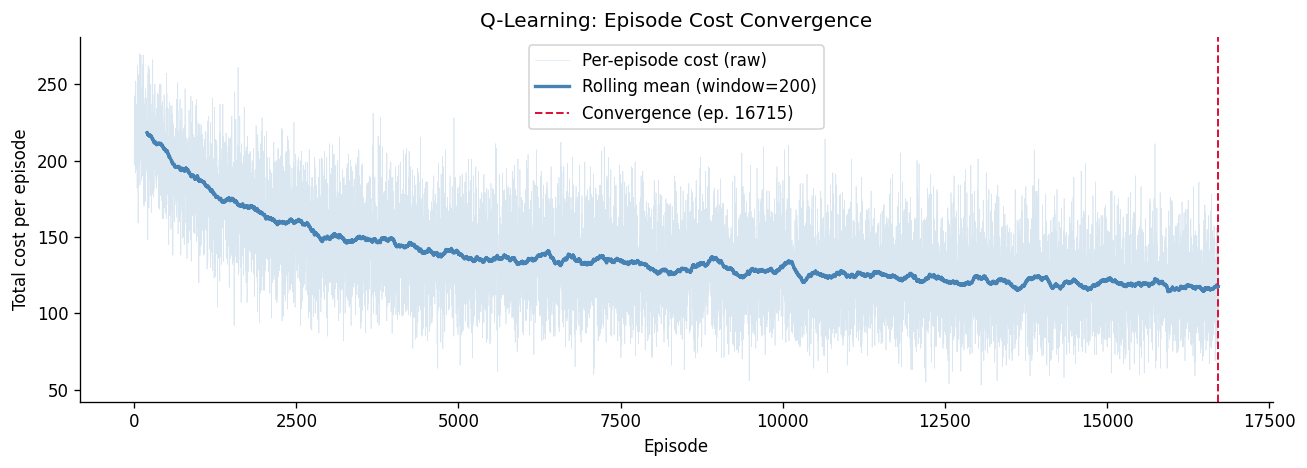

In [11]:
# Figure 1: Per-episode total cost
fig, ax = plt.subplots(figsize=(11, 4))

window   = 200
smoothed = np.convolve(costs_main, np.ones(window) / window, mode="valid")
x_smooth = np.arange(window - 1, len(costs_main))

ax.plot(costs_main, color="steelblue", alpha=0.2, linewidth=0.4, label="Per-episode cost (raw)")
ax.plot(x_smooth, smoothed, color="steelblue", linewidth=2,
        label=f"Rolling mean (window={window})")
ax.axvline(conv_main, color="crimson", linestyle="--", linewidth=1.2,
           label=f"Convergence (ep. {conv_main})")

ax.set_xlabel("Episode")
ax.set_ylabel("Total cost per episode")
ax.set_title("Q-Learning: Episode Cost Convergence")
ax.legend()
plt.tight_layout()
plt.savefig("fig_episode_costs.pdf", bbox_inches="tight")
plt.show()

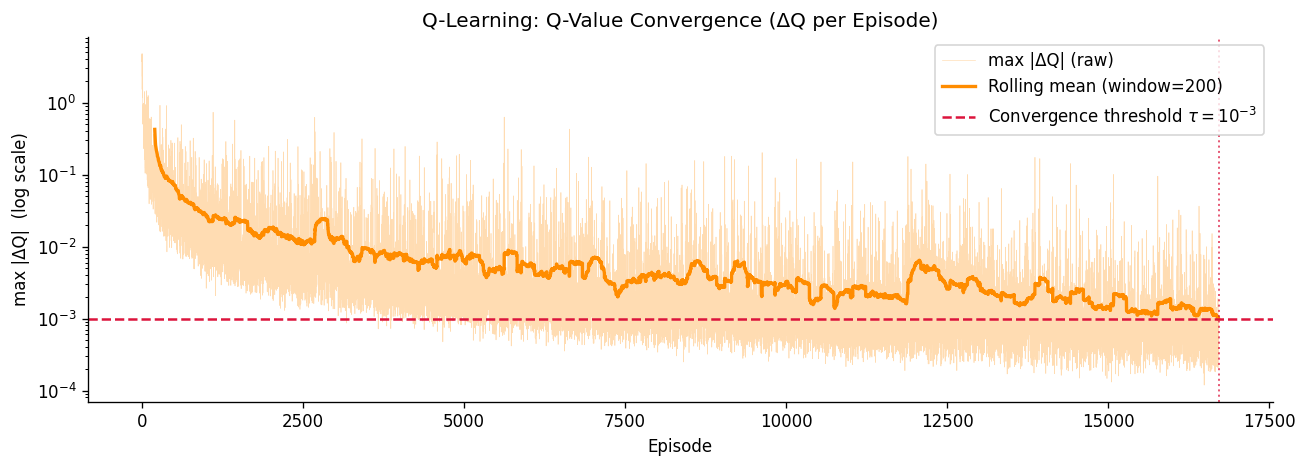

In [12]:
# Figure 2: delta_Q per episode (log scale) — our primary convergence metric
fig, ax = plt.subplots(figsize=(11, 4))

ax.semilogy(dq_main, color="darkorange", alpha=0.3, linewidth=0.4, label="max |ΔQ| (raw)")

if len(dq_main) >= 200:
    dq_smooth = np.convolve(dq_main, np.ones(200) / 200, mode="valid")
    ax.semilogy(np.arange(199, len(dq_main)), dq_smooth,
                color="darkorange", linewidth=2, label="Rolling mean (window=200)")

ax.axhline(1e-3, color="crimson", linestyle="--", linewidth=1.5,
           label=r"Convergence threshold $\tau=10^{-3}$")
ax.axvline(conv_main, color="crimson", linestyle=":", linewidth=1.2, alpha=0.7)

ax.set_xlabel("Episode")
ax.set_ylabel("max |ΔQ|  (log scale)")
ax.set_title("Q-Learning: Q-Value Convergence (ΔQ per Episode)")
ax.legend()
plt.tight_layout()
plt.savefig("fig_delta_q.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# Figure 3: Oracle MSE — how close V_QL(s) = min_a Q(s,a) is to V*(s)
if mse_main:
    eps_idx, mse_vals = zip(*mse_main)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.semilogy(eps_idx, mse_vals, color="seagreen", linewidth=1.5,
                marker=".", markersize=2, label="Oracle MSE")
    ax.axvline(conv_main, color="crimson", linestyle="--", linewidth=1.2,
               label=f"Convergence (ep. {conv_main})")

    ax.set_xlabel("Episode")
    ax.set_ylabel(r"$\mathbb{E}_s[(V_{QL}(s) - V^*(s))^2]$  (log scale)")
    ax.set_title("Q-Learning: Oracle MSE vs. Policy Iteration Ground Truth")
    ax.legend()
    plt.tight_layout()
    plt.savefig("fig_oracle_mse.pdf", bbox_inches="tight")
    plt.show()
else:
    print("Oracle not provided — MSE plot skipped.")

## 6 — Optimal Policy

We extract the greedy policy $\pi^*(s) = \arg\min_a Q(s,a)$ and display it in the
same table format as Assignment 1 for direct comparison.

**Note on REP states** (REP_1, REP_2): these have a single forced action
(`continue maintenance`) and are excluded from the comparison tables — they always
match by construction.

In [14]:
policy_QL = extract_policy(Q_main)

loc_names = {
    DEPOT: "DEPOT",
    AT_1 : "AT Machine 1",
    AT_2 : "AT Machine 2",
}

print("=" * 60)
print("Q-LEARNING POLICY")
print("=" * 60)
for loc, name in loc_names.items():
    print_policy_table(policy_QL, loc, f"Q-Learning — {name}")

print()
print("=" * 60)
print("POLICY ITERATION POLICY  (ground truth)")
print("=" * 60)
for loc, name in loc_names.items():
    print_policy_table(policy_PI, loc, f"PI — {name}")

Q-LEARNING POLICY

Q-Learning — DEPOT
          x2=0      x2=1      x2=2      x2=3      x2=4      x2=5      x2=6      x2=7
x1=0  travel_1  travel_2   nothing  travel_2  travel_2  travel_2  travel_2  travel_2
x1=1   nothing  travel_1   nothing   nothing  travel_2  travel_2  travel_2  travel_2
x1=2  travel_1  travel_1  travel_1  travel_1  travel_1  travel_2  travel_2  travel_2
x1=3  travel_1  travel_1  travel_1  travel_1  travel_1   nothing  travel_1  travel_2
x1=4  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_2
x1=5  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_1  travel_2

Q-Learning — AT Machine 1
              x2=0        x2=1          x2=2          x2=3          x2=4          x2=5          x2=6          x2=7
x1=0  travel_depot     nothing  travel_depot  travel_depot  travel_depot  travel_depot  travel_depot  travel_depot
x1=1       nothing     nothing  travel_depot  travel_depot  travel_depot  travel_depot  travel_depot  travel_d

In [ ]:
# Policy comparison: QL vs PI
# Near-tie threshold: if the Q-value gap between the best and second-best
# action is below this, both actions are essentially equivalent.
NEAR_TIE_THRESHOLD = 0.05

exact_matches  = 0
near_tie_diffs = []
true_mismatches = []

for s in states:
    if s[2] in (REP_1, REP_2):
        continue  # forced-action states always match

    s_idx    = states_indexes[s]
    row      = Q_main[s_idx]
    fin_vals = np.sort(row[np.isfinite(row)])

    pi_action = policy_PI[s]
    ql_action = policy_QL[s]

    if pi_action == ql_action:
        exact_matches += 1
    else:
        gap   = float(fin_vals[1] - fin_vals[0]) if len(fin_vals) > 1 else 0.0
        entry = (s, pi_action, ql_action, gap)
        if gap < NEAR_TIE_THRESHOLD:
            near_tie_diffs.append(entry)
        else:
            true_mismatches.append(entry)

total = sum(1 for s in states if s[2] not in (REP_1, REP_2))

print(f"Non-forced states     : {total}")
print(f"Exact matches         : {exact_matches}  ({100 * exact_matches / total:.1f}%)")
print(f"Near-tie differences  : {len(near_tie_diffs)}  (Q-gap < {NEAR_TIE_THRESHOLD})")
print(f"True mismatches       : {len(true_mismatches)}")

if near_tie_diffs:
    print("\nNear-tie differences (both actions are essentially equivalent):")
    for s, pi_a, ql_a, gap in near_tie_diffs:
        print(f"  {s}:  PI={pi_a:<20s}  QL={ql_a:<20s}  Q-gap={gap:.4f}")

if true_mismatches:
    print("\nTrue mismatches (investigate these):")
    for s, pi_a, ql_a, gap in true_mismatches:
        print(f"  {s}:  PI={pi_a:<20s}  QL={ql_a:<20s}  Q-gap={gap:.4f}")

## 7 — Hyperparameter Sensitivity Study

We vary α₀ and ε₀ across a small grid to empirically verify that the chosen values
(α₀=1, ε₀=1) are superior or competitive. We measure:
- **Convergence episode**: fewer is better
- **Final mean cost**: lower is better (quality of learned policy)
- **Policy match with PI**: higher % is better

All configurations use the same seed (42) for a fair comparison.

In [9]:
import os, json as _json

# 4 x 2 grid: omega in {0.60, 0.70, 0.85, 1.00} x epsilon_0 in {0.5, 1.0}
# All omega values satisfy Robbins-Monro: 0.5 < omega <= 1
CONFIGS = [
    {"alpha_power": 1.00, "epsilon_0": 1.0, "label": "w=1.00, e=1.0"},
    {"alpha_power": 1.00, "epsilon_0": 0.5, "label": "w=1.00, e=0.5"},
    {"alpha_power": 0.85, "epsilon_0": 1.0, "label": "w=0.85, e=1.0"},
    {"alpha_power": 0.85, "epsilon_0": 0.5, "label": "w=0.85, e=0.5"},
    {"alpha_power": 0.70, "epsilon_0": 1.0, "label": "w=0.70, e=1.0"},
    {"alpha_power": 0.70, "epsilon_0": 0.5, "label": "w=0.70, e=0.5"},
    {"alpha_power": 0.60, "epsilon_0": 1.0, "label": "w=0.60, e=1.0"},
    {"alpha_power": 0.60, "epsilon_0": 0.5, "label": "w=0.60, e=0.5"},
]

RESULTS_FILE = "hyperparam_results.json"

if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE) as _f:
        _saved = _json.load(_f)
    study_results = _saved
    _done_labels  = {r["label"] for r in study_results}
    print(f"Loaded {len(study_results)} saved result(s). Skipping: {_done_labels}")
else:
    study_results = []
    _done_labels  = set()

total = sum(1 for s in states if s[2] not in (REP_1, REP_2))

for cfg in CONFIGS:
    if cfg["label"] in _done_labels:
        print(f"[skip] {cfg['label']}")
        continue

    print(f"Running: {cfg['label']}")
    Q_c, costs_c, dq_c, _, conv_c = qLearning(
        n_episodes       = 60_000,
        alpha_power      = cfg["alpha_power"],
        epsilon_0        = cfg["epsilon_0"],
        dq_tau           = 1e-4,
        consec_threshold = 20,
        seed             = 42,
    )
    policy_c = extract_policy(Q_c)
    n_match  = sum(
        1 for s in states
        if s[2] not in (REP_1, REP_2) and policy_c[s] == policy_PI[s]
    )
    match_pct  = 100.0 * n_match / total
    final_cost = (float(np.mean(costs_c[-500:]))
                  if len(costs_c) >= 500 else float(np.mean(costs_c)))

    result = {
        "label"     : cfg["label"],
        "conv"      : conv_c,
        "costs"     : costs_c,
        "dq"        : dq_c,
        "match_pct" : match_pct,
        "final_cost": final_cost,
    }
    study_results.append(result)

    with open(RESULTS_FILE, "w") as _f:
        _json.dump(study_results, _f)

    print(f"  Converged ep: {conv_c:>6d}   "
          f"Policy match: {match_pct:.1f}%   "
          f"Final cost: {final_cost:.2f}")
    print()

print("\nHyperparameter study complete.")


Loaded 4 saved result(s). Skipping: {'w=0.85, e=1.0', 'w=1.00, e=0.5', 'w=0.85, e=0.5', 'w=1.00, e=1.0'}
[skip] w=1.00, e=1.0
[skip] w=1.00, e=0.5
[skip] w=0.85, e=1.0
[skip] w=0.85, e=0.5
Running: w=0.70, e=1.0


Q-Learning:   0%|          | 0/60000 [00:00<?, ?it/s]

  Converged ep:  60000   Policy match: 95.1%   Final cost: 85.35

Running: w=0.70, e=0.5


Q-Learning:   0%|          | 0/60000 [00:00<?, ?it/s]

  Converged ep:  60000   Policy match: 96.5%   Final cost: 86.64

Running: w=0.60, e=1.0


Q-Learning:   0%|          | 0/60000 [00:00<?, ?it/s]

  Converged ep:  60000   Policy match: 94.4%   Final cost: 84.09

Running: w=0.60, e=0.5


Q-Learning:   0%|          | 0/60000 [00:00<?, ?it/s]

  Converged ep:  60000   Policy match: 94.4%   Final cost: 85.49


Hyperparameter study complete.


/var/folders/j3/c6lj_2051kdcm9d4lrwsyf0r0000gn/T/ipykernel_61650/1273412642.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _cmap  = _cm.get_cmap("tab10", len(study_results))


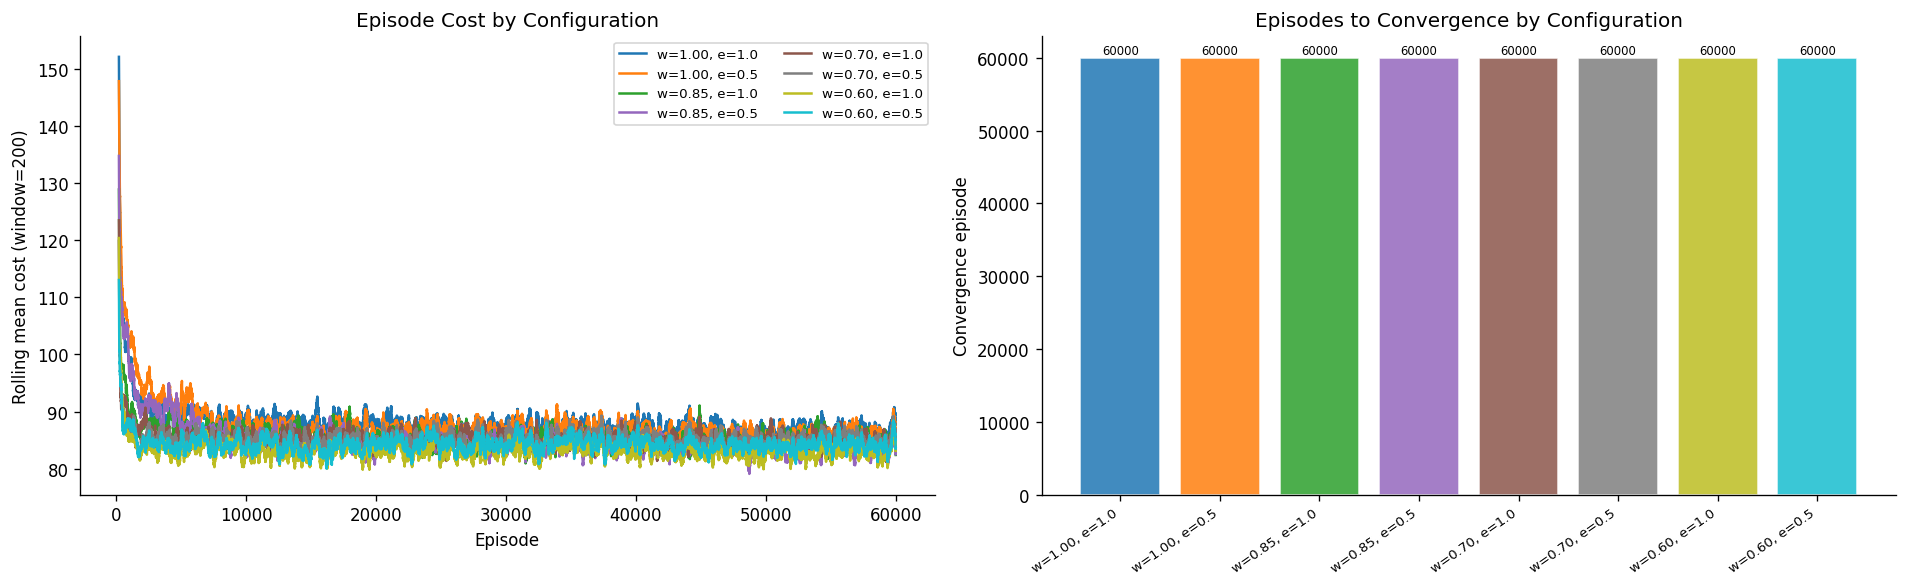

Configuration  Convergence ep. Policy match (%) Final mean cost
w=1.00, e=1.0            60000             93.1          88.602
w=1.00, e=0.5            60000             91.0          87.280
w=0.85, e=1.0            60000             95.8          84.474
w=0.85, e=0.5            60000             95.8          83.906
w=0.70, e=1.0            60000             95.1          85.346
w=0.70, e=0.5            60000             96.5          86.642
w=0.60, e=1.0            60000             94.4          84.094
w=0.60, e=0.5            60000             94.4          85.486


In [11]:
import matplotlib.cm as _cm

window = 200
_cmap  = _cm.get_cmap("tab10", len(study_results))
colors = [_cmap(i) for i in range(len(study_results))]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: smoothed episode cost curves
ax = axes[0]
for r, c in zip(study_results, colors):
    sm = np.convolve(r["costs"], np.ones(window) / window, mode="valid")
    ax.plot(np.arange(window - 1, len(r["costs"])), sm,
            color=c, linewidth=1.5, label=r["label"])
ax.set_xlabel("Episode")
ax.set_ylabel(f"Rolling mean cost (window={window})")
ax.set_title("Episode Cost by Configuration")
ax.legend(fontsize=8, ncol=2, loc="upper right")

# Panel 2: convergence episode bar chart
ax = axes[1]
labels = [r["label"] for r in study_results]
convs  = [r["conv"]  for r in study_results]
bars   = ax.bar(range(len(labels)), convs, color=colors, alpha=0.85, edgecolor="white")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Convergence episode")
ax.set_title("Episodes to Convergence by Configuration")
for bar, val in zip(bars, convs):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
        str(val), ha="center", va="bottom", fontsize=7,
    )

plt.tight_layout()
plt.savefig("fig_hyperparam_study.pdf", bbox_inches="tight")
plt.show()

df_study = pd.DataFrame([
    {
        "Configuration"    : r["label"],
        "Convergence ep."  : r["conv"],
        "Policy match (%)" : f"{r['match_pct']:.1f}",
        "Final mean cost"  : f"{r['final_cost']:.3f}",
    }
    for r in study_results
])
print(df_study.to_string(index=False))


In [12]:
# Pick any config result, e.g. the last one
r = study_results[-1]
dq = r["dq"]

print(f"Config:              {r['label']}")
print(f"Episodes run:        {len(dq)}")
print(f"Final max|ΔQ|:       {dq[-1]:.2e}")
print(f"Last 200 mean ΔQ:    {np.mean(dq[-200:]):.2e}")
print(f"Last 200 min ΔQ:     {np.min(dq[-200:]):.2e}")

Config:              w=0.60, e=0.5
Episodes run:        60000
Final max|ΔQ|:       2.18e-02
Last 200 mean ΔQ:    1.53e-02
Last 200 min ΔQ:     2.72e-03


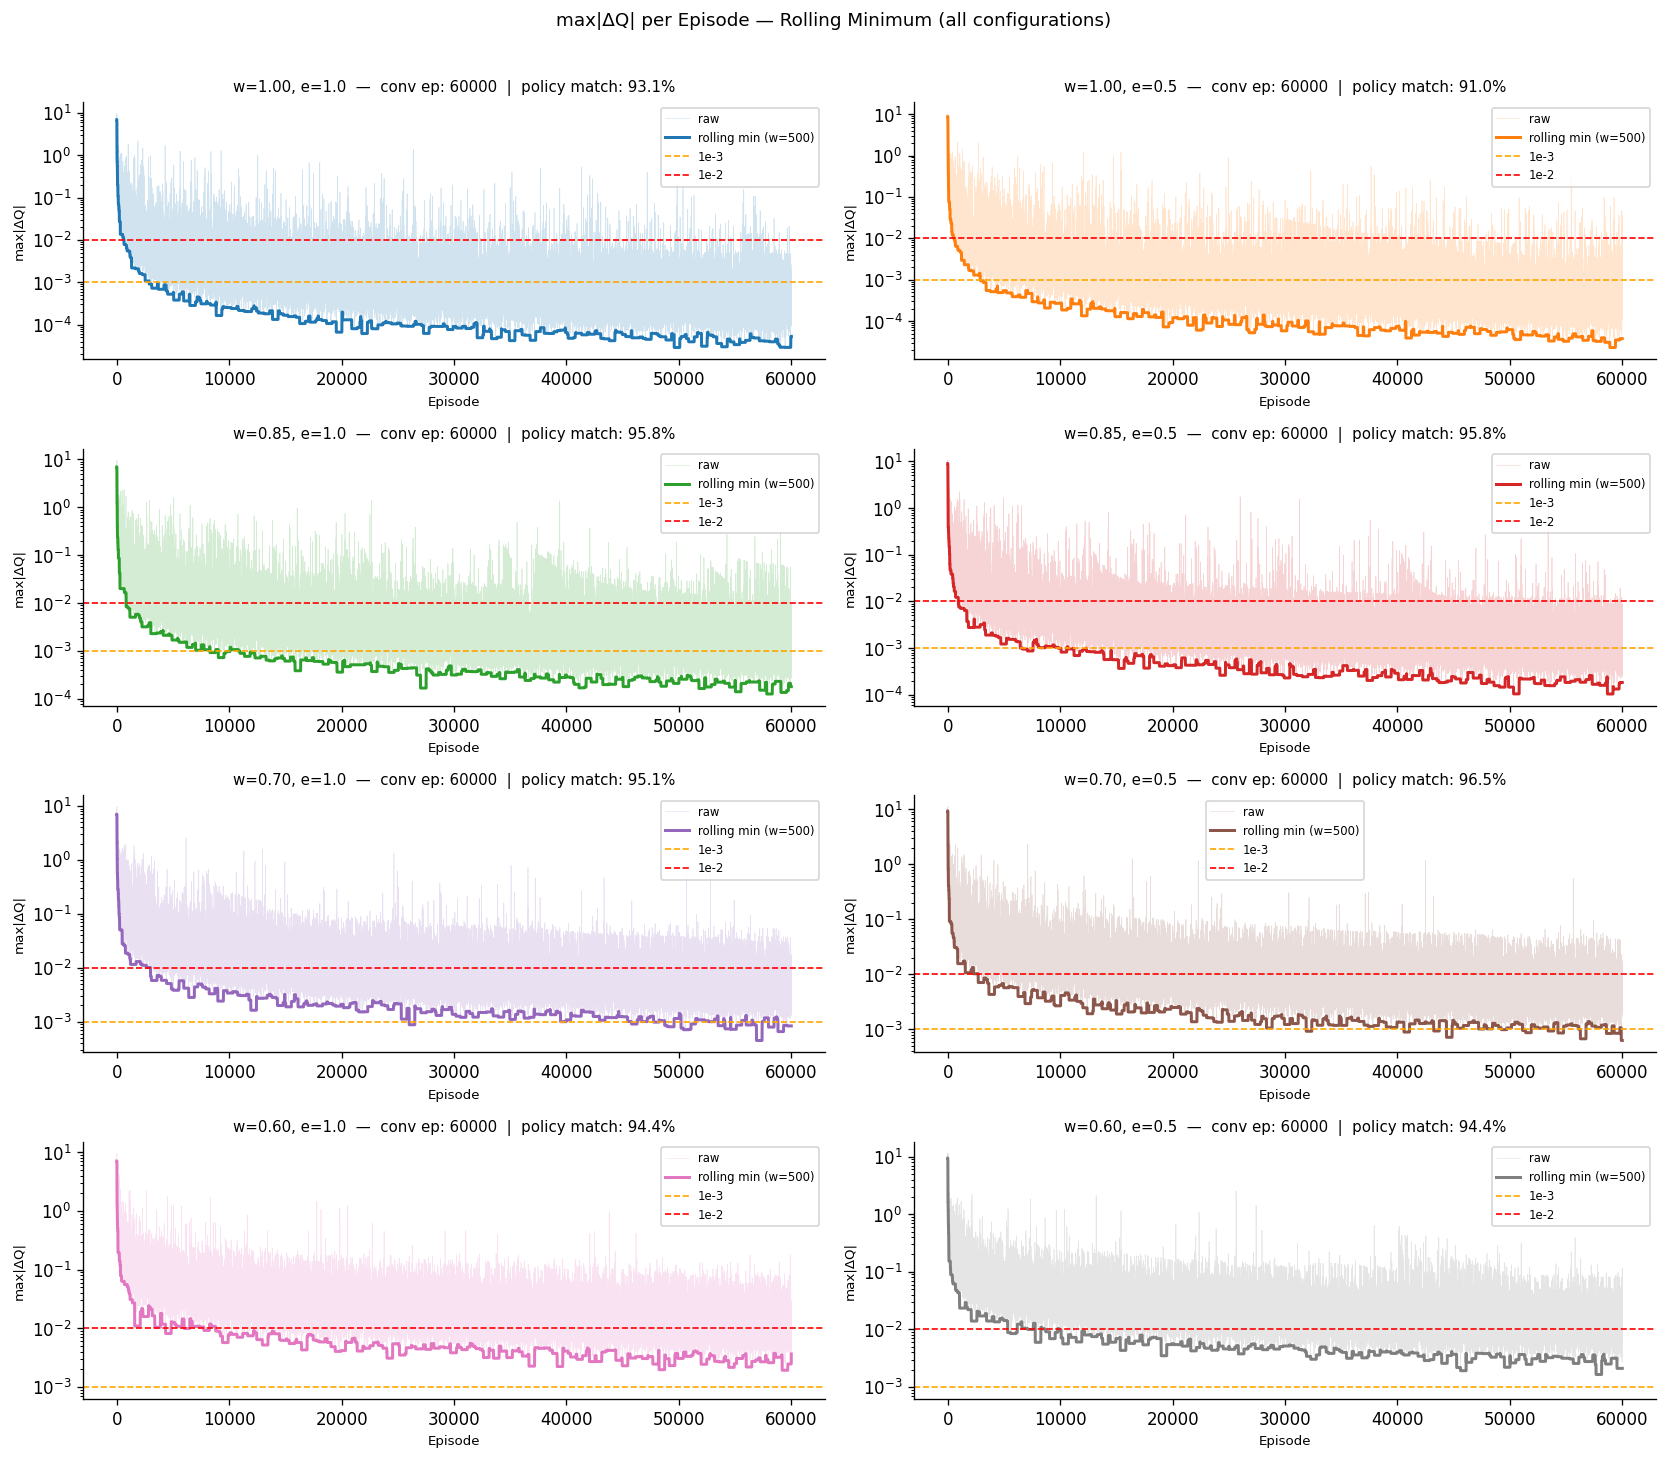

In [15]:
window = 500

n_configs = len(study_results)
n_cols = 2
n_rows = (n_configs + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3), sharex=False)
axes = axes.flatten()

for i, r in enumerate(study_results):
    ax   = axes[i]
    dq   = r["dq"]

    # Rolling minimum: at each episode, the lowest max|ΔQ| seen in the last `window` episodes
    rolling_min = [np.min(dq[max(0, j - window): j + 1]) for j in range(len(dq))]

    ax.semilogy(dq, color=f"C{i}", linewidth=0.4, alpha=0.2, label="raw")
    ax.semilogy(rolling_min, color=f"C{i}", linewidth=1.8, label=f"rolling min (w={window})")
    ax.axhline(1e-3, color="orange", ls="--", linewidth=1, label="1e-3")
    ax.axhline(1e-2, color="red",    ls="--", linewidth=1, label="1e-2")

    ax.set_title(
        f"{r['label']}  —  conv ep: {r['conv']}  |  policy match: {r['match_pct']:.1f}%",
        fontsize=9
    )
    ax.set_xlabel("Episode", fontsize=8)
    ax.set_ylabel("max|ΔQ|",  fontsize=8)
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("max|ΔQ| per Episode — Rolling Minimum (all configurations)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("fig_dq_rolling_min.pdf", bbox_inches="tight")
plt.show()